# AE signed-PV alignment versus shelf constraint

## Updated hypothesis and present evidence

The corrected hypothesis is that AEs align with signed $\nabla PV$, whereas CEs oppose it. The completed notebooks currently show:

- Planetary-dominated AEs have a broadly equatorward tendency, but alignment is moderate rather than tight (median mismatch about $61.8^\circ$).
- As topographic influence increases, AE preference error rises and the aligned fraction falls. This is **loss of PV-aligned directional coherence**, not evidence that AEs always continue to align.
- In the first near/far comparison, 124 AEs had a mean near-minus-far error of only about $+5.0^\circ$ with a standard deviation near $50.5^\circ$. Tilt distance increased by about 5.3 km on average, while log topographic/planetary ratio increased by about 0.72.
- Mechanical shelf cancellation is therefore **not yet demonstrated**: proximity and forcing were confounded, and tilt was not suppressed on average.

This notebook now asks a narrower question: after comparing near- and far-shelf observations at similar PV-gradient ratios within the same AE, does proximity independently degrade alignment, suppress the preferred along-$\nabla PV$ displacement, or redirect tilt?


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import distance_transform_edt
HERE=Path.cwd().resolve()
ANALYSIS_ROOT=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS_ROOT is None: raise FileNotFoundError('Run below seacofs_eddy_tilt_analysis.')
for path in (ANALYSIS_ROOT,ANALYSIS_ROOT/'case_studies'):
 if str(path) not in sys.path: sys.path.insert(0,str(path))
import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig,add_pv_alignment_diagnostics
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',80)


## 1. Rebuild gradients and audit the convention

Southern Hemisphere planetary beta must be positive and its signed gradient should point approximately northward. Stop here if these checks fail.


In [2]:
DOMINANCE_FACTOR=2.0
MIN_TILT_km=5.0
ALIGNMENT_DEG=45.0
RANDOM_TOLERANCE_FRACTION=ALIGNMENT_DEG/180.0
paths=tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)
df,_=tilt.load_tilt_tables(paths)
df=tilt.add_region_labels(df,grid)
df=tilt.add_pv_gradient_terms(df,grid,core_mean=True)
d=add_pv_alignment_diagnostics(df,PVAlignmentConfig(
 dominance_factor=DOMINANCE_FACTOR,min_tilt_distance_km=MIN_TILT_km))
d=d[d.direction_valid].replace([np.inf,-np.inf],np.nan).copy()
print('Planetary beta range:',d.beta.min(),d.beta.max())
print('Median planetary-gradient bearing:',d.PV_grad_plan_theta.median())
assert d.beta.dropna().median()>0,'Expected positive beta in the Southern Hemisphere.'


Planetary beta range: 1.75564771613126e-11 2.0786869653181334e-11
Median planetary-gradient bearing: 0.0


## 2. Define the response and independent shelf proxies

For AEs, zero preference error means alignment. For CEs, zero means opposition. Coast distance is only a geometric proxy; it is kept separate from depth, slope and the topographic/planetary PV ratio.


In [3]:
d['raw_mismatch']=d.dtheta_PV_grad
d['preference_error']=np.where(d.Cyc.eq('AE'),d.raw_mismatch,180.0-d.raw_mismatch)
d['within_tolerance']=d.preference_error<=ALIGNMENT_DEG
d['response_cosine']=np.cos(np.deg2rad(d.raw_mismatch))
d['slope_mag']=np.hypot(d.dhdx,d.dhdy)
d['log_topo_plan']=d.topo_plan_ratio
dx=float(np.nanmedian(np.abs(np.diff(grid.X_grid,axis=0))))
dy=float(np.nanmedian(np.abs(np.diff(grid.Y_grid,axis=1))))
coast_distance=distance_transform_edt(grid.mask_rho.astype(bool),sampling=(dx,dy))
d['coast_distance_km']=coast_distance[d.ic.astype(int),d.jc.astype(int)]
display(d.groupby('Cyc').agg(observations=('Eddy','size'),eddies=('Eddy','nunique'),
 median_raw_mismatch=('raw_mismatch','median'),
 median_preference_error=('preference_error','median'),
 predicted_fraction=('within_tolerance','mean')).round(3))


,observations,eddies,median_raw_mismatch,median_preference_error,predicted_fraction
Cyc,,,,,
AE,49268,1421,86.895,86.895,0.264
CE,46397,1530,114.781,65.219,0.367


## 3. Full planetary-to-topographic transition

Do not preselect topographic cases. The observed AE result is a transition from moderate alignment in planetary conditions toward weak coherence and eventual opposition as topographic influence strengthens. CEs show the complementary, much stronger transition toward opposition.

The dotted probability line is the correct random-orientation expectation, $\mathrm{ALIGNMENT\_DEG}/180$. It updates automatically if the tolerance is changed from $30^\circ$ to $45^\circ$.


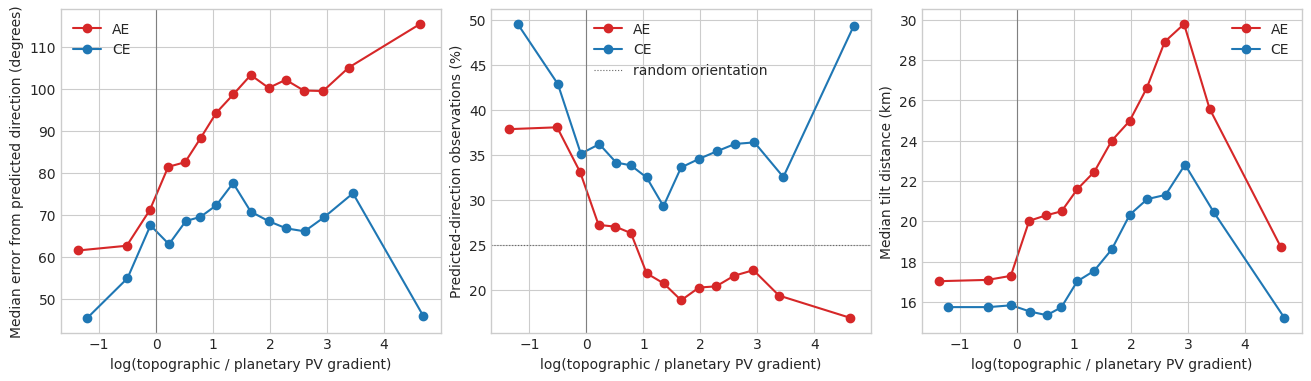

In [4]:
use=d.dropna(subset=['log_topo_plan','preference_error','coast_distance_km']).copy()
use['regime_bin']=pd.qcut(use.log_topo_plan,15,duplicates='drop')
stats=(use.groupby(['Cyc','regime_bin'],observed=True)
 .agg(x=('log_topo_plan','median'),error=('preference_error','median'),
 p_within_tolerance=('within_tolerance','mean'),distance=('coast_distance_km','median'),
 tilt=('TiltDis','median'),eddies=('Eddy','nunique')).reset_index())
fig,axs=plt.subplots(1,3,figsize=(13,3.7),constrained_layout=True)
for cyc,color in [('AE','tab:red'),('CE','tab:blue')]:
 part=stats[stats.Cyc==cyc]
 axs[0].plot(part.x,part.error,'-o',color=color,label=cyc)
 axs[1].plot(part.x,100*part.p_within_tolerance,'-o',color=color,label=cyc)
 axs[2].plot(part.x,part.tilt,'-o',color=color,label=cyc)
axs[0].set_ylabel('Median error from predicted direction (degrees)')
axs[1].axhline(100*RANDOM_TOLERANCE_FRACTION,color='0.4',ls=':',lw=.8,label='random orientation')
axs[1].set_ylabel('Predicted-direction observations (%)')
axs[2].set_ylabel('Median tilt distance (km)')
for ax in axs: ax.axvline(0,color='0.5',lw=.8);ax.set_xlabel('log(topographic / planetary PV gradient)');ax.legend(frameon=False)


## 4. Descriptive proximity comparison within PV-ratio strata

This is a descriptive screen. Near and far curves are compared inside broad PV-ratio strata and across multiple distance cutoffs. A proximity effect should recur across neighbouring strata and reasonable cutoffs; an isolated separation is not convincing. The decisive matched within-eddy analysis follows below.


,cutoff_km,ratio_bin,near,preference_error,p_within_tolerance,tilt_km,observations,eddies
0,25,"(-5.5360000000000005, -0.828]",False,61.114138,0.379947,17.013363,4927,535
1,25,"(-0.828, -0.279]",False,63.019382,0.379541,17.044240,4927,659
2,25,"(-0.279, 0.112]",False,71.721150,0.322915,17.599094,4927,749
3,25,"(0.112, 0.516]",False,82.938672,0.268372,19.973816,4926,811
4,25,"(0.516, 0.926]",False,85.631487,0.265679,20.628518,4927,842
5,25,"(0.926, 1.335]",False,96.440839,0.214779,21.689038,4926,841
7,25,"(1.335, 1.759]",False,100.855595,0.199269,23.603305,4923,794
9,25,"(1.759, 2.183]",False,100.164782,0.198780,25.023515,4920,738
11,25,"(2.183, 2.709]",False,101.904512,0.206967,27.597517,4909,649
13,25,"(2.709, 5.805]",False,103.487389,0.205646,26.154802,4853,466


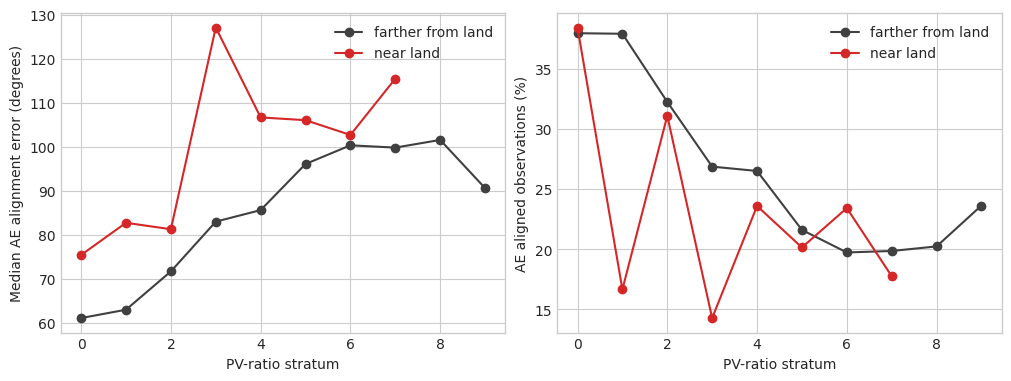

In [5]:
ae=use[use.Cyc=='AE'].copy()
ae['ratio_stratum']=pd.qcut(ae.log_topo_plan,10,duplicates='drop')
rows=[]
for cutoff in [25,50,100,150,200]:
 ae['near']=ae.coast_distance_km<=cutoff
 for (ratio_bin,near),part in ae.groupby(['ratio_stratum','near'],observed=True):
  rows.append({'cutoff_km':cutoff,'ratio_bin':ratio_bin,'near':near,
   'preference_error':part.preference_error.median(),
   'p_within_tolerance':part.within_tolerance.mean(),'tilt_km':part.TiltDis.median(),
   'observations':len(part),'eddies':part.Eddy.nunique()})
proximity=pd.DataFrame(rows)
display(proximity[proximity.eddies>=10].head(30))
fig,axs=plt.subplots(1,2,figsize=(10,3.7),constrained_layout=True)
for near,label,color in [(False,'farther from land','0.25'),(True,'near land','tab:red')]:
 part=proximity[(proximity.cutoff_km==100)&(proximity.near==near)&(proximity.eddies>=10)]
 x=np.arange(len(part));axs[0].plot(x,part.preference_error,'-o',color=color,label=label)
 axs[1].plot(x,100*part.p_within_tolerance,'-o',color=color,label=label)
axs[0].set(xlabel='PV-ratio stratum',ylabel='Median AE alignment error (degrees)')
axs[1].set(xlabel='PV-ratio stratum',ylabel='AE aligned observations (%)')
for ax in axs: ax.legend(frameon=False)


## 5. Unadjusted within-eddy shelf encounter

This reproduces the initial near-minus-far comparison. It controls for stable differences between eddies, but not for the fact that PV ratio changes as an eddy approaches the shelf. Treat it as a diagnostic and compare it with the PV-ratio-matched analysis below.


,count,mean,std,min,25%,50%,75%,max
Eddy,124.0,1493.677419,860.740384,11.000000,745.000000,1536.000000,2167.000000,2971.000000
near_minus_far_error,124.0,4.947426,50.532264,-154.406259,-27.555138,3.842703,40.930215,148.994706
near_minus_far_tilt_km,124.0,5.292763,21.234213,-63.867179,-5.511932,3.419383,12.366876,74.432683
near_minus_far_log_ratio,124.0,0.715373,1.307984,-2.215468,-0.094414,0.441078,1.000724,4.571889
n_near,124.0,15.612903,10.882753,3.000000,7.000000,13.500000,21.000000,77.000000
n_far,124.0,30.637097,37.934332,3.000000,9.000000,16.000000,36.250000,268.000000


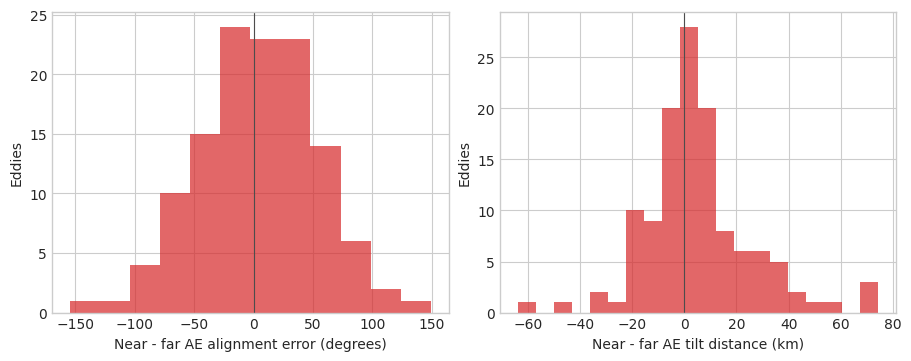

In [6]:
ae=use[use.Cyc=='AE'].copy();ae['near_100km']=ae.coast_distance_km<=100
rows=[]
for eddy,part in ae.groupby('Eddy'):
 if part.near_100km.nunique()<2: continue
 far=part[~part.near_100km];near=part[part.near_100km]
 if min(len(far),len(near))<3: continue
 rows.append({'Eddy':eddy,
  'near_minus_far_error':near.preference_error.median()-far.preference_error.median(),
  'near_minus_far_tilt_km':near.TiltDis.median()-far.TiltDis.median(),
  'near_minus_far_log_ratio':near.log_topo_plan.median()-far.log_topo_plan.median(),
  'n_near':len(near),'n_far':len(far)})
paired=pd.DataFrame(rows);display(paired.describe().T)
fig,axs=plt.subplots(1,2,figsize=(9,3.5),constrained_layout=True)
axs[0].hist(paired.near_minus_far_error,bins='fd',color='tab:red',alpha=.7)
axs[1].hist(paired.near_minus_far_tilt_km,bins='fd',color='tab:red',alpha=.7)
axs[0].set(xlabel='Near - far AE alignment error (degrees)',ylabel='Eddies')
axs[1].set(xlabel='Near - far AE tilt distance (km)',ylabel='Eddies')
for ax in axs: ax.axvline(0,color='0.3',lw=.8)


## 6. Within-eddy, PV-ratio-matched proximity test

For every near-land AE observation, find the closest far-land observation from the same eddy in log topographic/planetary PV ratio. Retain only pairs within a stated caliper. This asks whether proximity changes the response when PV forcing is approximately comparable.

Primary outcomes are alignment error, tilt distance, the signed tilt component along the topographic signed-PV direction, and the absolute transverse component. Because signed topographic $\nabla PV$ normally points offshore/deeper, a positive along-gradient component is the AE-preferred component. Mechanical constraint would require that component to weaken near the shelf after matching PV ratio. Results are summarized per eddy and bootstrapped over eddies.


In [7]:
MATCH_CALIPER_LOG_RATIO=0.25
NEAR_DISTANCE_km=100.0
ae=use[use.Cyc.eq('AE')].dropna(subset=[
 'dtheta_PV_grad_topo','PV_grad_topo_theta','TiltDir','TiltDis']).copy()
ae['near']=ae.coast_distance_km<=NEAR_DISTANCE_km
angle_signed=(ae.TiltDir-ae.PV_grad_topo_theta+180.0)%360.0-180.0
ae['tilt_along_topo_PV_km']=ae.TiltDis*np.cos(np.deg2rad(angle_signed))
ae['tilt_across_topo_PV_km']=ae.TiltDis*np.sin(np.deg2rad(angle_signed))
matched_rows=[]
for eddy,part in ae.groupby('Eddy'):
 near=part[part.near];far=part[~part.near]
 if near.empty or far.empty: continue
 far_ratio=far.log_topo_plan.to_numpy()
 for idx,row in near.iterrows():
  j=np.argmin(np.abs(far_ratio-row.log_topo_plan));control=far.iloc[j]
  gap=abs(row.log_topo_plan-control.log_topo_plan)
  if gap>MATCH_CALIPER_LOG_RATIO: continue
  matched_rows.append({'Eddy':eddy,'near_index':idx,'far_index':control.name,'ratio_gap':gap,
   'error_diff':row.preference_error-control.preference_error,
   'tilt_diff_km':row.TiltDis-control.TiltDis,
   'along_diff_km':row.tilt_along_topo_PV_km-control.tilt_along_topo_PV_km,
   'abs_across_diff_km':abs(row.tilt_across_topo_PV_km)-abs(control.tilt_across_topo_PV_km)})
matched_pairs=pd.DataFrame(matched_rows)
eddy_effects=(matched_pairs.groupby('Eddy',as_index=False)
 .agg(pairs=('error_diff','size'),median_ratio_gap=('ratio_gap','median'),
      error_diff=('error_diff','median'),tilt_diff_km=('tilt_diff_km','median'),
      along_diff_km=('along_diff_km','median'),
      abs_across_diff_km=('abs_across_diff_km','median')))
print(f'{len(matched_pairs):,} matched pairs from {eddy_effects.Eddy.nunique():,} AEs')
display(eddy_effects.describe().T)


1,356 matched pairs from 145 AEs


,count,mean,std,min,25%,50%,75%,max
Eddy,145.0,1474.586207,897.845466,6.000000,684.000000,1567.000000,2170.000000,2971.000000
pairs,145.0,9.351724,9.497464,1.000000,3.000000,6.000000,13.000000,72.000000
median_ratio_gap,145.0,0.070528,0.058874,0.002954,0.022080,0.049208,0.113476,0.246519
error_diff,145.0,3.043563,44.889406,-127.790482,-18.274316,4.597868,25.055621,153.599343
tilt_diff_km,145.0,5.089033,23.175423,-121.571168,-5.690611,3.135881,12.797407,82.002477
along_diff_km,145.0,0.018224,23.191632,-96.343710,-10.578596,-1.914969,12.168455,56.237606
abs_across_diff_km,145.0,2.571876,23.234017,-133.120725,-6.359490,1.004308,8.627602,88.293817


## 7. Eddy-clustered uncertainty for the matched effects

The bootstrap sampling unit is the eddy, not the daily observation. An interval excluding zero is evidence of a recurring proximity effect after approximate PV-ratio matching. Report the prespecified estimate and interval rather than selecting the most favourable threshold.


,outcome,median,low_95,high_95
0,error_diff,4.598,-0.867,8.847
1,tilt_diff_km,3.136,0.427,4.470
2,along_diff_km,-1.915,-5.435,1.689
3,abs_across_diff_km,1.004,-0.451,2.214


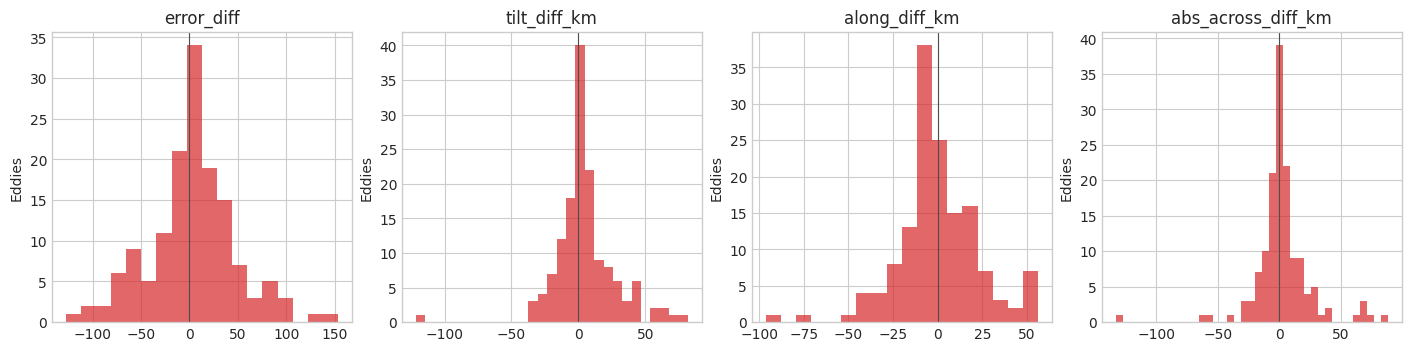

In [8]:
def bootstrap_eddy_median(frame,columns,n_boot=5000,seed=42):
 rng=np.random.default_rng(seed);values=frame[columns].dropna();observed=values.median()
 boot=np.empty((n_boot,len(columns)))
 for b in range(n_boot):
  sample=values.iloc[rng.integers(0,len(values),len(values))]
  boot[b]=sample.median().to_numpy()
 return pd.DataFrame({'outcome':columns,'median':observed.to_numpy(),
  'low_95':np.percentile(boot,2.5,axis=0),'high_95':np.percentile(boot,97.5,axis=0)})
effect_columns=['error_diff','tilt_diff_km','along_diff_km','abs_across_diff_km']
matched_uncertainty=bootstrap_eddy_median(eddy_effects,effect_columns)
display(matched_uncertainty.round(3))
fig,axs=plt.subplots(1,4,figsize=(14,3.4),constrained_layout=True)
for ax,column in zip(axs,effect_columns):
 ax.hist(eddy_effects[column].dropna(),bins='fd',color='tab:red',alpha=.7)
 ax.axvline(0,color='0.3',lw=.8);ax.set(title=column,ylabel='Eddies')


## 8. Sensitivity to proximity definition and matching caliper

Repeat the matched calculation over prespecified coast-distance thresholds and calipers. A real shelf-proximity effect should retain its sign across a reasonable part of this grid. This is a sensitivity analysis, not a search for the combination with the largest effect.


In [9]:
def matched_effects_for_settings(frame,distance_km,caliper):
 part=frame.copy();part['near']=part.coast_distance_km<=distance_km;rows=[]
 for eddy,g in part.groupby('Eddy'):
  near=g[g.near];far=g[~g.near]
  if near.empty or far.empty: continue
  ratios=far.log_topo_plan.to_numpy()
  for _,row in near.iterrows():
   j=np.argmin(np.abs(ratios-row.log_topo_plan));control=far.iloc[j]
   if abs(row.log_topo_plan-control.log_topo_plan)>caliper: continue
   rows.append({'Eddy':eddy,'error':row.preference_error-control.preference_error,
    'tilt':row.TiltDis-control.TiltDis,
    'along':row.tilt_along_topo_PV_km-control.tilt_along_topo_PV_km})
 if not rows:return None
 pairs=pd.DataFrame(rows);eddy=pairs.groupby('Eddy')[['error','tilt','along']].median()
 return {'distance_km':distance_km,'caliper':caliper,'eddies':len(eddy),
  'error_median':eddy.error.median(),'tilt_median':eddy.tilt.median(),
  'along_median':eddy.along.median()}
sensitivity=[]
for distance in [50,75,100,150,200]:
 for caliper in [0.10,0.25,0.50]:
  result=matched_effects_for_settings(ae,distance,caliper)
  if result is not None:sensitivity.append(result)
sensitivity=pd.DataFrame(sensitivity)
display(sensitivity.round(3))


,distance_km,caliper,eddies,error_median,tilt_median,along_median
0,50,0.10,69,-3.912,1.220,-0.831
1,50,0.25,78,-2.212,-0.544,-0.756
2,50,0.50,78,-2.817,-0.544,-0.592
3,75,0.10,132,2.199,-0.863,-0.737
4,75,0.25,142,2.867,-1.007,-0.631
5,75,0.50,148,2.028,-0.478,-0.306
6,100,0.10,129,4.974,4.275,-1.873
7,100,0.25,145,4.598,3.136,-1.915
8,100,0.50,153,4.598,2.956,-2.221
9,150,0.10,270,-6.827,0.873,1.413


## 9. Updated interpretation rules

The current outputs establish **loss of AE PV-aligned coherence with increasing topographic influence**. They do not yet establish physical shelf cancellation.

Upgrade the conclusion only if the matched analysis shows all of the following:

1. Near-shelf alignment error increases after matching PV ratio within eddies.
2. The preferred along-signed-topographic-PV component decreases, or transverse displacement increases consistently.
3. Eddy-bootstrap intervals exclude zero and signs are robust to reasonable coast-distance and caliper choices.
4. Depth, latitude, region, slope, eddy age and translation/advection do not explain the response.

If only the angle broadens, retain **loss of directional coherence**. A formal follow-up should use a circular or cosine response with smooth PV-ratio and coast-distance effects, their interaction, and eddy/region grouping. An event study around first shelf encounter remains preferable once translation velocity and a locally defined shelf-normal direction are available.
